In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import h5py
import numpy as np

train_h5 = h5py.File("/content/drive/MyDrive/morph_project/processed/train.h5", "r")
test_h5  = h5py.File("/content/drive/MyDrive/morph_project/processed/test.h5", "r")

X_train_ds = train_h5["X"]
y_train_ds = train_h5["y"]

X_test_ds = test_h5["X"]
y_test_ds = test_h5["y"]

print("Train samples:", X_train_ds.shape[0])
print("Test samples:", X_test_ds.shape[0])


Mounted at /content/drive
Train samples: 7177
Test samples: 1803


In [ ]:
from skimage.feature import hog
from tqdm import tqdm

def hog_features_from_hdf5(hdf5_array, batch_size=500):
    features = []
    total = len(hdf5_array)

    for i in tqdm(range(0, total, batch_size)):
        batch = hdf5_array[i:i+batch_size]  # streamed slice

        for img in batch:
            feat = hog(
                img,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                channel_axis=-1
            )
            features.append(feat)

    return np.array(features)


In [ ]:
X_train_hog = hog_features_from_hdf5(X_train_ds, batch_size=500)
X_test_hog  = hog_features_from_hdf5(X_test_ds, batch_size=500)

y_train = np.array(y_train_ds)
y_test  = np.array(y_test_ds)

print("HOG extraction finished.")


100%|██████████| 4/4 [01:24<00:00, 21.22s/it]


HOG extraction finished.


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train_hog, y_train)

pred = svm.predict(X_test_hog)
acc = accuracy_score(y_test, pred)

print("SVM Accuracy:", acc)


SVM Accuracy: 0.8369384359400999


In [ ]:
import joblib, os

MODEL_DIR = "/content/drive/MyDrive/morph_project/models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(svm, os.path.join(MODEL_DIR, "svm_hog_model.pkl"))
print("Model saved.")


Model saved.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib, os

MODEL_PATH = "/content/drive/MyDrive/morph_project/models/svm_hog_model.pkl"
svm = joblib.load(MODEL_PATH)

print("Model-1 Loaded ✅")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model-1 Loaded ✅


In [ ]:
import h5py
import numpy as np

BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")

h5_test = h5py.File(os.path.join(PROC, "test.h5"), "r")
X_test = h5_test["X"]
y_test = np.array(h5_test["y"])
print("Loaded test dataset ✅")


Loaded test dataset ✅


In [ ]:
import cv2
from skimage.feature import hog
from tqdm import tqdm

def hog_features_batch(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        feats.append(hog_feat)
    return np.array(feats)

def hog_from_hdf5(X_ds, batch=200):
    outputs = []
    for i in tqdm(range(0, X_ds.shape[0], batch), desc="Extracting HOG"):
        outputs.append(hog_features_batch(X_ds[i:i+batch]))
    return np.concatenate(outputs, axis=0)

X_test_hog = hog_from_hdf5(X_test)
print("HOG features extracted ✅")


Extracting HOG: 100%|██████████| 10/10 [01:00<00:00,  6.01s/it]


HOG features extracted ✅


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = svm.predict(X_test_hog)

print("Model-1 Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Au","Tp"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Model-1 Accuracy: 0.834165280088741
              precision    recall  f1-score   support

          Au       0.85      0.98      0.91      1489
          Tp       0.59      0.15      0.24       314

    accuracy                           0.83      1803
   macro avg       0.72      0.56      0.57      1803
weighted avg       0.80      0.83      0.79      1803

Confusion Matrix:
 [[1457   32]
 [ 267   47]]


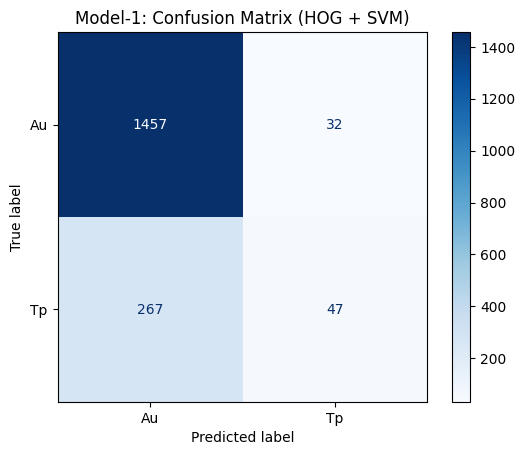

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm, display_labels=["Au","Tp"]).plot(cmap="Blues")
plt.title("Model-1: Confusion Matrix (HOG + SVM)")
plt.show()


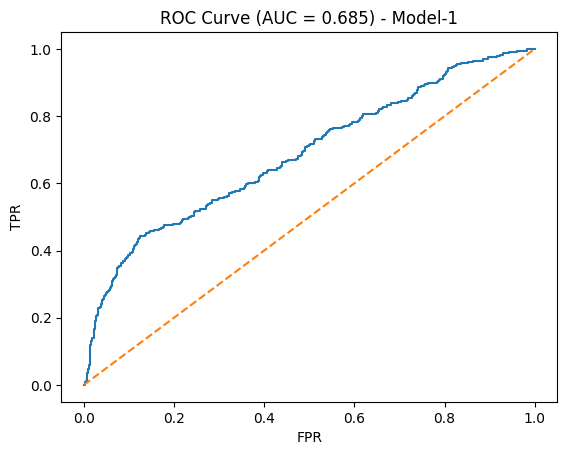

In [ ]:
from sklearn.metrics import roc_curve, auc

probs = svm.decision_function(X_test_hog)
fpr, tpr, _ = roc_curve(y_test, probs)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f"ROC Curve (AUC = {round(auc_score,3)}) - Model-1")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


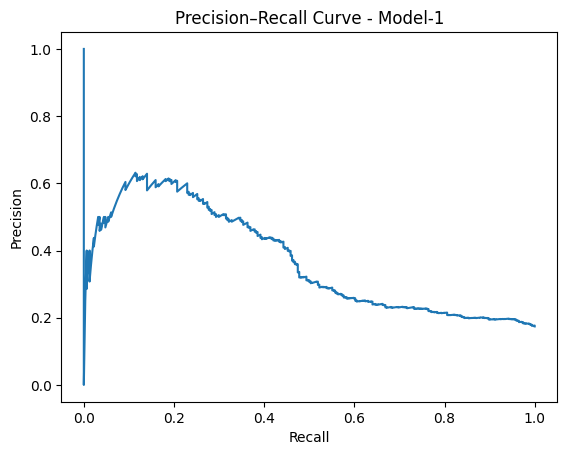

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.title("Precision–Recall Curve - Model-1")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


In [ ]:
from google.colab import files
import numpy as np

def predict_uploaded_model1():
    uploaded = files.upload()
    for fname in uploaded.keys():
        img_bgr = cv2.imread(fname)
        if img_bgr is None:
            print("Could not read:", fname)
            continue

        # Resize first
        img = cv2.resize(img_bgr, (224,224))

        # Denoise while still uint8
        img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

        # Histogram equalization
        img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
        img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
        img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

        # Now convert to float
        img = img.astype(np.float32) / 255.0

        # HOG features
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys',
            feature_vector=True
        ).reshape(1,-1)

        pred = svm.predict(feat)[0]
        prob = svm.predict_proba(feat)[0][1]

        print("\nUploaded:", fname)
        print("Prediction:", ["Au","Tp"][pred])
        print("Confidence:", round(prob*100,2), "%")

predict_uploaded_model1()


Saving cpymv1.png to cpymv1.png

Uploaded: cpymv1.png
Prediction: Au
Confidence: 12.72 %
